In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [31]:
f_train_high = os.path.expanduser("~/Desktop/Machine_learning_2/LOLv1/train/high")
train_high = [f for f in os.listdir(f_train_high) if f.endswith(('.jpg', '.jpeg', '.png', '.gif'))]

f_train_low = os.path.expanduser("~/Desktop/Machine_learning_2/LOLv1/train/low")
train_low = [f for f in os.listdir(f_train_low) if f.endswith(('.jpg', '.jpeg', '.png', '.gif'))]




f_test_high = os.path.expanduser("~/Desktop/Machine_learning_2/LOLv1/test/high")
test_high = [f for f in os.listdir(f_test_high) if f.endswith(('.jpg', '.jpeg', '.png', '.gif'))]

f_test_low = os.path.expanduser("~/Desktop/Machine_learning_2/LOLv1/test/low")
test_low = [f for f in os.listdir(f_test_low) if f.endswith(('.jpg', '.jpeg', '.png', '.gif'))]


In [34]:
def load_images(folder, filenames, size=(256, 256)):
    folder = os.path.expanduser(folder)
    images = []
    for f in filenames:
        img = Image.open(os.path.join(folder, f)).convert("RGB")
        img = img.resize(size)                        # resize to consistent shape
        img = np.array(img) / 255.0                   # normalize to [0, 1]
        images.append(img)
    return np.array(images)

In [50]:
set_size=(128, 128)
train_high_imgs = load_images("~/Desktop/Machine_learning_2/LOLv1/train/high", train_high,size=set_size)
train_low_imgs  = load_images("~/Desktop/Machine_learning_2/LOLv1/train/low",  train_low,size=set_size)
test_high_imgs  = load_images("~/Desktop/Machine_learning_2/LOLv1/test/high",  test_high,size=set_size)
test_low_imgs   = load_images("~/Desktop/Machine_learning_2/LOLv1/test/low",   test_low,size=set_size)

In [51]:


class LOLDataset(Dataset):
    def __init__(self, low_imgs, high_imgs):
        # Convert numpy arrays to tensors, move channels first (N,H,W,C) -> (N,C,H,W)
        self.low  = torch.tensor(low_imgs,  dtype=torch.float32).permute(0, 3, 1, 2)
        self.high = torch.tensor(high_imgs, dtype=torch.float32).permute(0, 3, 1, 2)

    def __len__(self):
        return len(self.low)

    def __getitem__(self, idx):
        return self.low[idx], self.high[idx]

# Create dataloaders
train_dataset = LOLDataset(train_low_imgs, train_high_imgs)
test_dataset  = LOLDataset(test_low_imgs,  test_high_imgs)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False)

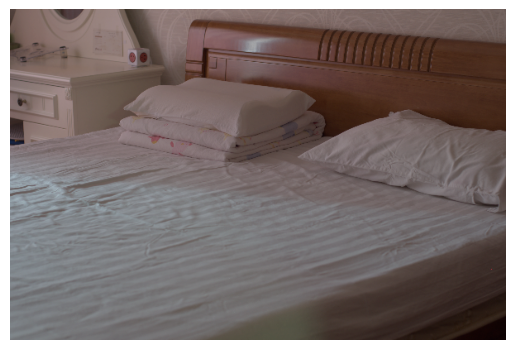

In [27]:
img = mpimg.imread(os.path.join(f_train_high, train_high[1]))
plt.imshow(img)
plt.axis('off')  # hide axes
plt.show()


In [19]:
img = mpimg.imread(os.path.join(folder, test_high[1]))
img.shape

(400, 600, 3)

In [81]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = DoubleConv(3, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        # Decoder
        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec1 = DoubleConv(256, 128)  # 256 because of skip connection
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)
        self.up3 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec3 = DoubleConv(64, 32)

        # Output
        self.out = nn.Conv2d(32, 3, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder
        c1 = self.enc1(x)
        c2 = self.enc2(self.pool(c1))
        c3 = self.enc3(self.pool(c2))

        # Bottleneck
        b = self.bottleneck(self.pool(c3))

        # Decoder + skip connections
        u1 = self.up1(b)
        u1 = torch.cat([u1, c3], dim=1)
        u1 = self.dec1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, c2], dim=1)
        u2 = self.dec2(u2)

        u3 = self.up3(u2)
        u3 = torch.cat([u3, c1], dim=1)
        u3 = self.dec3(u3)

        return self.sigmoid(self.out(u3))

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")  # mps = Mac GPU
print(f"Using device: {device}")

model     = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 10

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for low, high in train_loader:
        low, high = low.to(device), high.to(device)

        optimizer.zero_grad()
        pred = model(low)
        loss = criterion(pred, high)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

   

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss/len(train_loader):.4f} ")

Using device: cpu
Epoch 1/10 | Train Loss: 0.0373 
Epoch 2/10 | Train Loss: 0.0315 
Epoch 3/10 | Train Loss: 0.0310 


In [83]:
for epoch in range(epochs):
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for low, high in test_loader:
            low, high = low.to(device), high.to(device)
            pred = model(low)
            val_loss += criterion(pred, high).item()

    print(f"Epoch {epoch+1}/{epochs} | Val Loss: {val_loss/len(test_loader):.4f}")

Epoch 1/10 | Val Loss: 0.0316
Epoch 2/10 | Val Loss: 0.0316
Epoch 3/10 | Val Loss: 0.0316
Epoch 4/10 | Val Loss: 0.0316
Epoch 5/10 | Val Loss: 0.0316
Epoch 6/10 | Val Loss: 0.0316
Epoch 7/10 | Val Loss: 0.0316
Epoch 8/10 | Val Loss: 0.0316
Epoch 9/10 | Val Loss: 0.0316
Epoch 10/10 | Val Loss: 0.0316


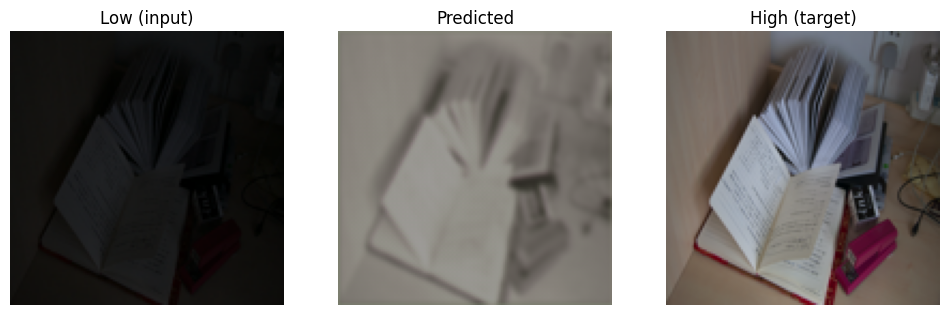

In [80]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    low, high = next(iter(test_loader))
    pred = model(low.to(device)).cpu()

# Convert back (C,H,W) -> (H,W,C) for plotting
imgnum = 7
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(low[imgnum].permute(1,2,0));  axes[0].set_title("Low (input)")
axes[1].imshow(pred[imgnum].permute(1,2,0)); axes[1].set_title("Predicted")
axes[2].imshow(high[imgnum].permute(1,2,0)); axes[2].set_title("High (target)")
for ax in axes: ax.axis('off')
plt.show()